# Generating samples and detecting anomalies with GMMs

The goal of the lab is to build a generative model of images with a GMM model. We will:
- Create a GMM class with methods implementing the E-step, M-step, and training loop.
- Implement methods allowing to compute the full likelihood (to check convergence) and sample images.
- We will use the model to detect *anomalies*, which will be numbers we left aside initially.

We will work with the ```digits``` datasets for simplicity - but you can apply it to MNIST easily. It is composed of ```8 x 8``` images with labels being digits (*0 to 9*).

### Loading data

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

np.random.seed(0)

In [42]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data / 16.0       # shape (1797, 64) which we normalize into pixel values in [0, 1]
y = digits.target      # shape (1797,)

print(X.shape, y.shape)

(1797, 64) (1797,)


In [43]:
import pandas as pd
df = pd.DataFrame(y)
df.value_counts()

,count
0,
3,183
1,182
5,182
4,181
6,181
9,180
7,179
0,178
2,177


### Loading a subset of data

We create a small function to select a subset of the data according to the label:
<div class='alert alert-block alert-info'>
            Code:</div>

In [44]:
def load_digits_subset(digits, X, y):
    X_out = []
    y_out = []
    # Keep data with labels in digits
    mask = np.isin(y, digits)
    y_out = y[mask]
    X_out = X[mask]

    return np.array(X_out), np.array(y_out)

# Digits used for training
train_digits = [0,1,2,3,4]
X_train, y_train = load_digits_subset(train_digits, X, y)

print("Training data shape:", X_train.shape)

Training data shape: (901, 64)


### Creating the GMM model

We create a class with the necessary hyperparameters:
- The number of clusters *K*
- The number of features *p*

And the necessary parameters:
- The mixture distribution $\pi$
- The means $\mu_k$
- The covariance matrix $\Sigma_k$. **To simplify the code, we limite our covariance matrix to be diagonal** and hence only need a scalar $\sigma_k$ for each cluster.


Use the ```log_gaussian_diag``` function defined in the next cell !
<div class='alert alert-block alert-info'>
            Code:</div>

We also need to implement the log-density computation for each distribution in order to compute the E-step. We can also use it to keep track of the likelihood during training:

<div class='alert alert-block alert-info'>
            Code:</div>

In [45]:
def log_gaussian_diag(X, mu, sigma, eps=1e-8):
    """
    Log density of N(mu, sigma^2 I) for each row x in X.

    X: (n, p)
    mu: (p,)
    sigma: scalar (std)
    returns: (n,)
    """
    sigma = max(float(sigma), eps)
    n_features = X.shape[1]
    diff2 = (X - mu) ** 2
    sq_norm = np.sum(diff2, axis=1)  # (n,)

    constant_term = -0.5 * n_features * np.log(2 * np.pi)
    log_sigma_term = -n_features * np.log(sigma)
    quadratic_term = -0.5 * sq_norm / (sigma ** 2)

    return constant_term + log_sigma_term + quadratic_term

In [46]:
def logsumexp(a, axis=None, keepdims=False):
    """Stable log(sum(exp(a)))"""
    m = np.max(a, axis=axis, keepdims=True)
    out = m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out

In [47]:
class DiagonalGMM:
    def __init__(self, n_components, n_features):
        # Hyperparameters
        rng = np.random.default_rng()
        self.K = n_components
        self.p = n_features
        self.alpha = 1e-8 # To avoid underflow and probabilities rounded down to 0
        # Parameters
        self.pi = rng.random(size=(self.K)) # Initialize to random distribution
        self.pi = self.pi/np.sum(self.pi)
        self.mu = rng.normal(size=(self.K, self.p)) # Initialize randomly using univariate gaussian
        self.sigma = np.ones(self.K) #Diagonal covariance matrix - initialize at one

    def e_step(self, X):
        n = X.shape[0]
        log_r = np.zeros((n, self.K))
        #	Compute the log-posterior probabilities of the latent variable = the responsabilities
        for k in range(self.K):
            log_prior = np.log(self.pi[k] + self.alpha)
            log_like = log_gaussian_diag(X, self.mu[k], self.sigma[k], eps=self.alpha)
            log_r[:, k] = log_prior + log_like

        # Normalize them and obtain probabilities
        log_norm = logsumexp(log_r, axis=1, keepdims=True)  # (n,1)
        log_r = log_r - log_norm
        r = np.exp(log_r)
        return r

    def m_step(self, X, r):
        n, p = X.shape
        K = r.shape[1]

        Nk = r.sum(axis=0) + self.alpha                       # (K,)

        # pi_k = Nk / n
        # Updating pi
        self.pi = Nk / n                         # (K,)

        # mu_k = (sum_i r_ik x_i) / Nk
        # Updating mu
        self.mu = (r.T @ X) / Nk[:, None]        # (K, p)

        #	Updating sigma
        # sigma_k^2 = (1/(p Nk)) * sum_i r_ik ||x_i - mu_k||^2
        diff = X[:, None, :] - self.mu[None, :, :]   # (n, K, p)
        sqdist = (diff ** 2).sum(axis=2)             # (n, K)
        var = (r * sqdist).sum(axis=0) / (p * Nk)    # (K,)

        self.sigma = np.sqrt(np.maximum(var, self.alpha)) # stds, (K,)


    def log_likelihood(self, X, per_sample=False):
        n = X.shape[0]
        log_prob = np.zeros((n, self.K))
        # Apply the formula
        # Easier to do iterating over clusters
        for k in range(self.K):
          log_prior = np.log(self.pi[k] + self.alpha)
          log_like = log_gaussian_diag(
              X,
              self.mu[k],
              self.sigma[k],
              eps=self.alpha
          )
          log_prob[:, k] = log_prior + log_like

        # log p(x_i) = log sum_k exp(log_prob[i,k])
        log_px = logsumexp(log_prob, axis=1)

        if per_sample:
            return log_px
        else:
            return np.sum(log_px)

    def fit(self, X, n_iters=20):
        log_liks = []
        for it in range(n_iters):
            #	Apply e-step, m-step, and compute and return the likelihood:
            r = self.e_step(X)
            self.m_step(X, r)
            log_l = self.log_likelihood(X)
            log_liks.append(log_l)
        return log_l

    def sample(self, n_samples, return_labels=False):
        #	Sample a vector of n_samples latent variable giving cluster id (from pi)
        # The sample is mu + a sample from a N(0,1) gaussian * sigma
        rng = np.random.default_rng()

        # 1) sample component ids z ~ Categorical(pi)
        z = rng.choice(self.K, size=n_samples, p=self.pi)

        # 2) sample eps ~ N(0, I_p)
        eps = rng.standard_normal(size=(n_samples, self.p))

        # 3) x = mu_z + sigma_z * eps
        X = self.mu[z] + self.sigma[z][:, None] * eps

        if return_labels:
          return X,z

        return X

### Training the model

We can now train the model. We should use more clusters than needed: **why ?**

Using several gaussians can compensate for restrictive assumptions (in this case, diagonal covariance) and improve approximation of complex regions.

Generally, **what would be the biggest issue with our training scheme** and what should we do to reduce it ?

The main problem is that our EM algorithm could converge to a bad local maximum. We should run EM several times with different initializations and keep the model with the highest final log-likelihood.

In [48]:
K = 8
D = X_train.shape[1]
# Create the model
gmm = DiagonalGMM(n_components=K, n_features=D)
# Train the
gmm.fit(X_train, n_iters=20)

np.float64(12614.593935220284)

We can visualize the means $\mu_k$ learned by the GMM. However, we will see that they are **blurry** !
- Why are they blurry ?
- When setting up our model, what assumption did we make about the pixels ?

The learned means are blurry because each GMM component averages many images with soft assignments, and small variations in digit shape and alignment are smoothed out.
Additionally, the model assumes pixel-wise independence (diagonal/isotropic covariance), ignoring spatial correlations between pixels, which prevents it from modeling sharp structures.

<div class='alert alert-block alert-info'>
            Code:</div>

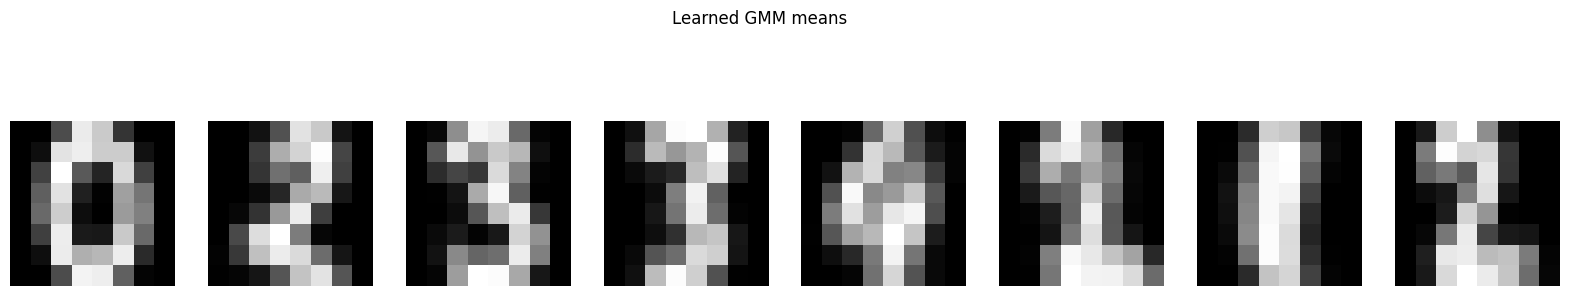

In [49]:
plt.figure(figsize=(20,4))
for k in range(K):
    plt.subplot(1, K, k+1)
    plt.imshow(gmm.mu[k].reshape(8,8), cmap='gray') # Corrected: use gmm.mu[k] and reshape it
    plt.axis('off')
plt.suptitle("Learned GMM means")
plt.show()

We can now generate a few samples by adding the appropriate method to the class. The process is easy:
- Pick a cluster $k$,
- Add the cluster mean $\mu_k$ to the variance times a randow draw $x \sim \mathcal{N}(0,1)$: $ \mu_k + \sigma_k \times x$

However, the results are not great. **What can we conclude about the likelihood of our model ?** What is missing ?

The poor samples indicate that although the model achieves high likelihood, it fails to capture spatial dependencies between pixels; what is missing is a structured prior or covariance that models pixel correlations.

<div class='alert alert-block alert-info'>
            Code:</div>

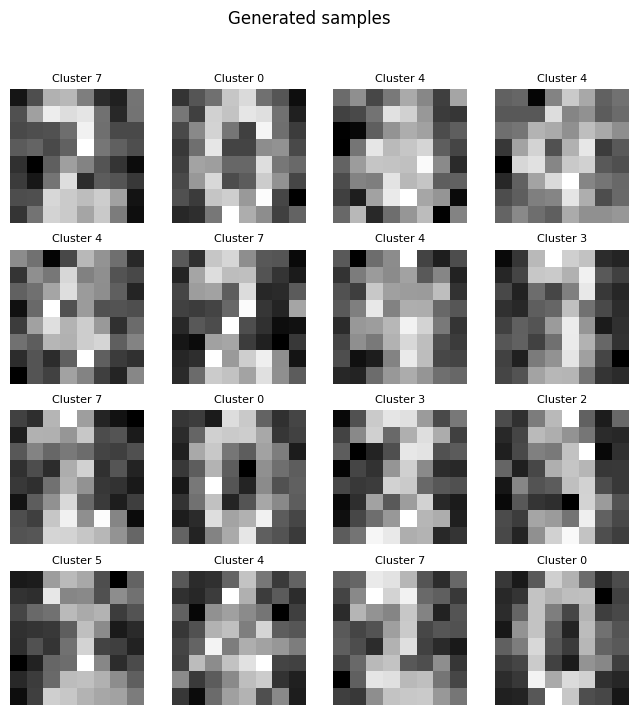

In [50]:
# Get samples from the appropriate method. Also get the cluster id from which they were samples
X_gen, z_gen = gmm.sample(n_samples=16, return_labels=True)

plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_gen[i].reshape(8,8), cmap='gray')
    plt.title(f"Cluster {z_gen[i]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Generated samples")
plt.show()

### Detecting anomalies

We will now use the remaining labels to check if our model is able to detect them as *anomalies*.

To do this, we need to compute their **likelihood according to our model**. Why should they have a lower likelihood than the other ?

They should have lower log-likelihood because the GMM was trained to assign high probability mass to the training distribution. The “left out” digits are out-of-distribution, so under the learned density they fall in low-density regions

In [51]:
left_out_digits = [5,6,7,8,9]
X_ood, y_ood = load_digits_subset(left_out_digits, X, y)

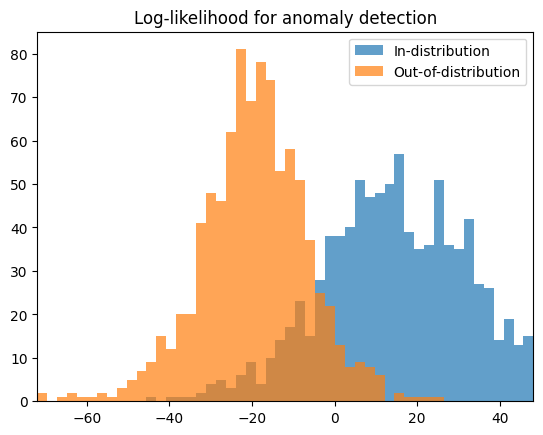

In [52]:
#	Compute the log-likelihoods
l_l_train = gmm.log_likelihood(X_train, per_sample=True)
l_l_ood = gmm.log_likelihood(X_ood, per_sample=True)

n_bins = 50
bins = np.linspace(np.min([l_l_train.min(), l_l_ood.min()]), np.max([l_l_train.max(), l_l_ood.max()]), n_bins + 1)

plt.hist(l_l_train, bins=bins, alpha=0.7, label="In-distribution")
plt.hist(l_l_ood, bins=bins, alpha=0.7, label="Out-of-distribution")
plt.legend()
plt.xlim(np.min([l_l_train.min(), l_l_ood.min()]), np.max([l_l_train.max(), l_l_ood.max()]))
plt.title("Log-likelihood for anomaly detection")
plt.show()